In [96]:
# Instalar scipy (solo necesario una vez)
!pip install scipy

In [97]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde
from scipy import signal
from scipy.fft import fft, fftfreq

In [98]:
def encontrar_fila_encabezado(archivo, palabra='ob_date'):
    with open(archivo, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if line.startswith(palabra):
                return i
    return None

# Ruta a la carpeta de precipitación
ruta_precip = "../datos/midas/precipitacion/"
archivos_precip = glob.glob(os.path.join(ruta_precip, "*00697*.csv"))
print(f"Archivos de precipitación encontrados: {len(archivos_precip)}")

lista_precip = []
for archivo in archivos_precip:
    #print(f"Procesando: {os.path.basename(archivo)}")
    try:
        fila_enc = encontrar_fila_encabezado(archivo)
        if fila_enc is None:
            #print(f"  No se encontró encabezado, se omite.")
            continue
        df = pd.read_csv(
            archivo,
            skiprows=fila_enc,
            header=0,
            na_values=['NA'],
            parse_dates=['ob_date']
        )
        df = df[df['ob_date'] != 'end data']
        lista_precip.append(df)
    except Exception as e:
        print(f"  Error al leer: {e}")
        continue

if lista_precip:
    df_precip_all = pd.concat(lista_precip, ignore_index=True)
    print(f"\nTotal registros combinados: {len(df_precip_all)}")
    # Filtrar por rango 1986-1998
    inicio = '1986-01-01'
    fin = '1998-06-31'
    df_precip = df_precip_all[(df_precip_all['ob_date'] >= inicio) & (df_precip_all['ob_date'] <= fin)].copy()
    print(f"Registros en período {inicio} a {fin}: {len(df_precip)}")
    
    # Seleccionar columnas útiles
    df_precip = df_precip[['ob_date', 'prcp_amt']].rename(columns={'ob_date': 'date', 'prcp_amt': 'precip'})
    df_precip['date'] = pd.to_datetime(df_precip['date'])
    df_precip = df_precip.sort_values('date').reset_index(drop=True)
    
    # Guardar
    df_precip.to_csv('../datos/midas_precip_stjames_1986_1998.csv', index=False)
    print("Archivo de precipitación guardado: ../datos/midas_precip_stjames_1986_1998.csv")
else:
    print("No se encontraron archivos de precipitación.")
    

def encontrar_fila_encabezado(archivo, palabra='ob_end_time'):
    with open(archivo, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if line.startswith(palabra):
                return i
    return None

ruta_temp = "../datos/midas/temperatura/"
archivos_temp = glob.glob(os.path.join(ruta_temp, "*00697*.csv"))
print(f"Archivos de temperatura encontrados: {len(archivos_temp)}")

lista_temp = []
for archivo in archivos_temp:
    #print(f"Procesando: {os.path.basename(archivo)}")
    try:
        fila_enc = encontrar_fila_encabezado(archivo)
        if fila_enc is None:
            print(f"  No se encontró encabezado, se omite.")
            continue
        df = pd.read_csv(
            archivo,
            skiprows=fila_enc,
            header=0,
            na_values=['NA'],
            parse_dates=['ob_end_time']
        )
        df = df[df['ob_end_time'] != 'end data']
        lista_temp.append(df)
    except Exception as e:
        print(f"  Error al leer: {e}")
        continue

# ============================================================
# para temperatura
# ============================================================

if lista_temp:
    df_temp_all = pd.concat(lista_temp, ignore_index=True)
    print(f"\nTotal registros combinados: {len(df_temp_all)}")
    
    # Calcular temperatura media diaria
    df_temp_all['tmean'] = (df_temp_all['max_air_temp'] + df_temp_all['min_air_temp']) / 2
    
    # Filtrar por rango 1986-1998
    inicio = '1986-01-01'
    fin = '1998-06-31'
    df_temp = df_temp_all[(df_temp_all['ob_end_time'] >= inicio) & (df_temp_all['ob_end_time'] <= fin)].copy()
    print(f"Registros en período {inicio} a {fin}: {len(df_temp)}")
    
    # Seleccionar columnas útiles
    df_temp = df_temp[['ob_end_time', 'tmean']].rename(columns={'ob_end_time': 'date'})
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp = df_temp.sort_values('date').reset_index(drop=True)
    
    # Limpieza de outliers (opcional, puedes ajustar rangos)
    df_temp = df_temp[(df_temp['tmean'] >= -20) & (df_temp['tmean'] <= 40)]
    
    # Guardar
    df_temp.to_csv('../datos/midas_temp_stjames_1986_1998.csv', index=False)
    print("Archivo de temperatura guardado: ../datos/midas_temp_stjames_1986_1998.csv")
else:
    print("No se encontraron archivos de temperatura.")
    

Archivos de precipitación encontrados: 20

Total registros combinados: 6609
Registros en período 1986-01-01 a 1998-06-31: 5893
Archivo de precipitación guardado: ../datos/midas_precip_stjames_1986_1998.csv
Archivos de temperatura encontrados: 20

Total registros combinados: 8636
Registros en período 1986-01-01 a 1998-06-31: 4534
Archivo de temperatura guardado: ../datos/midas_temp_stjames_1986_1998.csv


In [99]:
# ============================================================
# Cargar datos (ajusta la ruta si es necesario)
# ============================================================
df_interp = pd.read_csv('../datos/midas_stjames_1986_1998_interp.csv', parse_dates=['date'])
df_interp.rename(columns={'tmean': 'tmean_interp', 'precip': 'precip_interp'}, inplace=True)

# Crear columnas auxiliares para agregaciones
df_interp['year'] = df_interp['date'].dt.year
df_interp['month'] = df_interp['date'].dt.month
df_interp['dayofyear'] = df_interp['date'].dt.dayofyear

# ============================================================
# Función para determinar la estación
# ============================================================
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    else:
        return 'SON'

df_interp['season'] = df_interp['month'].apply(get_season)
season_map = {'DJF': '01', 'MAM': '04', 'JJA': '07', 'SON': '10'}


# ---- Agregaciones para temperatura (media) ----
# Mensual
monthly_temp = df_interp.groupby(['year', 'month'], as_index=False)['tmean_interp'].mean()
monthly_temp['date'] = pd.to_datetime(monthly_temp[['year', 'month']].assign(day=1))

# Anual
annual_temp = df_interp.groupby('year', as_index=False)['tmean_interp'].mean()
annual_temp['date'] = pd.to_datetime(annual_temp['year'], format='%Y')

# Estacional
seasonal_temp = df_interp.groupby(['year', 'season'], as_index=False)['tmean_interp'].mean()
seasonal_temp['date'] = pd.to_datetime(seasonal_temp['year'].astype(str) + '-' +
                                         seasonal_temp['season'].map(season_map) + '-01')

# ---- Climatologías y anomalías para temperatura ----
# Diaria
clim_daily_temp = df_interp.groupby('dayofyear')['tmean_interp'].mean().reset_index().rename(
    columns={'tmean_interp': 'clim_daily'})
df_interp = df_interp.merge(clim_daily_temp, on='dayofyear')
df_interp['tmean_anom_daily'] = df_interp['tmean_interp'] - df_interp['clim_daily']

# Mensual
clim_monthly_temp = monthly_temp.groupby('month')['tmean_interp'].mean().reset_index().rename(
    columns={'tmean_interp': 'clim_monthly'})
monthly_temp = monthly_temp.merge(clim_monthly_temp, on='month')
monthly_temp['tmean_anom'] = monthly_temp['tmean_interp'] - monthly_temp['clim_monthly']

# Anual
clim_annual_temp = annual_temp['tmean_interp'].mean()
annual_temp['tmean_anom'] = annual_temp['tmean_interp'] - clim_annual_temp

# Estacional
clim_seasonal_temp = seasonal_temp.groupby('season')['tmean_interp'].mean().reset_index().rename(
    columns={'tmean_interp': 'clim_seasonal'})
seasonal_temp = seasonal_temp.merge(clim_seasonal_temp, on='season')
seasonal_temp['tmean_anom'] = seasonal_temp['tmean_interp'] - seasonal_temp['clim_seasonal']


# ---- Agregaciones para precipitación (suma) ----
# Mensual
monthly_precip = df_interp.groupby(['year', 'month'], as_index=False)['precip_interp'].sum()
monthly_precip['date'] = pd.to_datetime(monthly_precip[['year', 'month']].assign(day=1))

# Anual
annual_precip = df_interp.groupby('year', as_index=False)['precip_interp'].sum()
annual_precip['date'] = pd.to_datetime(annual_precip['year'], format='%Y')

# Estacional
seasonal_precip = df_interp.groupby(['year', 'season'], as_index=False)['precip_interp'].sum()
seasonal_precip['date'] = pd.to_datetime(seasonal_precip['year'].astype(str) + '-' +
                                           seasonal_precip['season'].map(season_map) + '-01')

# ---- Climatologías y anomalías para precipitación ----
# Diaria
clim_daily_precip = df_interp.groupby('dayofyear')['precip_interp'].mean().reset_index().rename(
    columns={'precip_interp': 'clim_daily_precip'})
df_interp = df_interp.merge(clim_daily_precip, on='dayofyear')
df_interp['precip_anom_daily'] = df_interp['precip_interp'] - df_interp['clim_daily_precip']

# Mensual
clim_monthly_precip = monthly_precip.groupby('month')['precip_interp'].mean().reset_index().rename(
    columns={'precip_interp': 'clim_monthly_precip'})
monthly_precip = monthly_precip.merge(clim_monthly_precip, on='month')
monthly_precip['precip_anom'] = monthly_precip['precip_interp'] - monthly_precip['clim_monthly_precip']

# Anual
clim_annual_precip = annual_precip['precip_interp'].mean()
annual_precip['precip_anom'] = annual_precip['precip_interp'] - clim_annual_precip

# Estacional
clim_seasonal_precip = seasonal_precip.groupby('season')['precip_interp'].mean().reset_index().rename(
    columns={'precip_interp': 'clim_seasonal_precip'})
seasonal_precip = seasonal_precip.merge(clim_seasonal_precip, on='season')
seasonal_precip['precip_anom'] = seasonal_precip['precip_interp'] - seasonal_precip['clim_seasonal_precip']





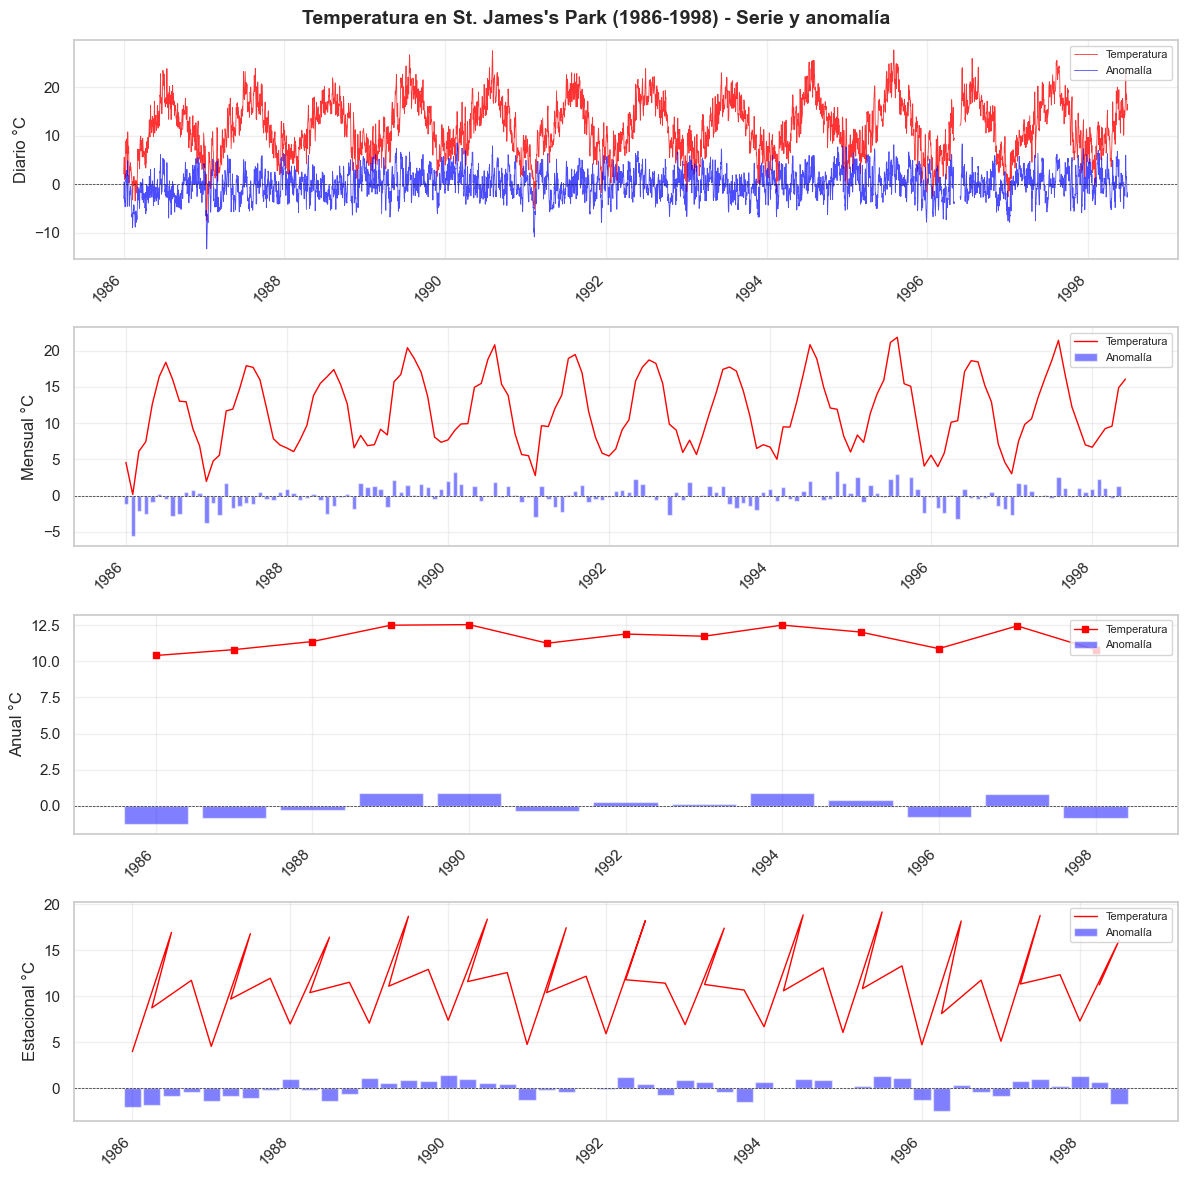

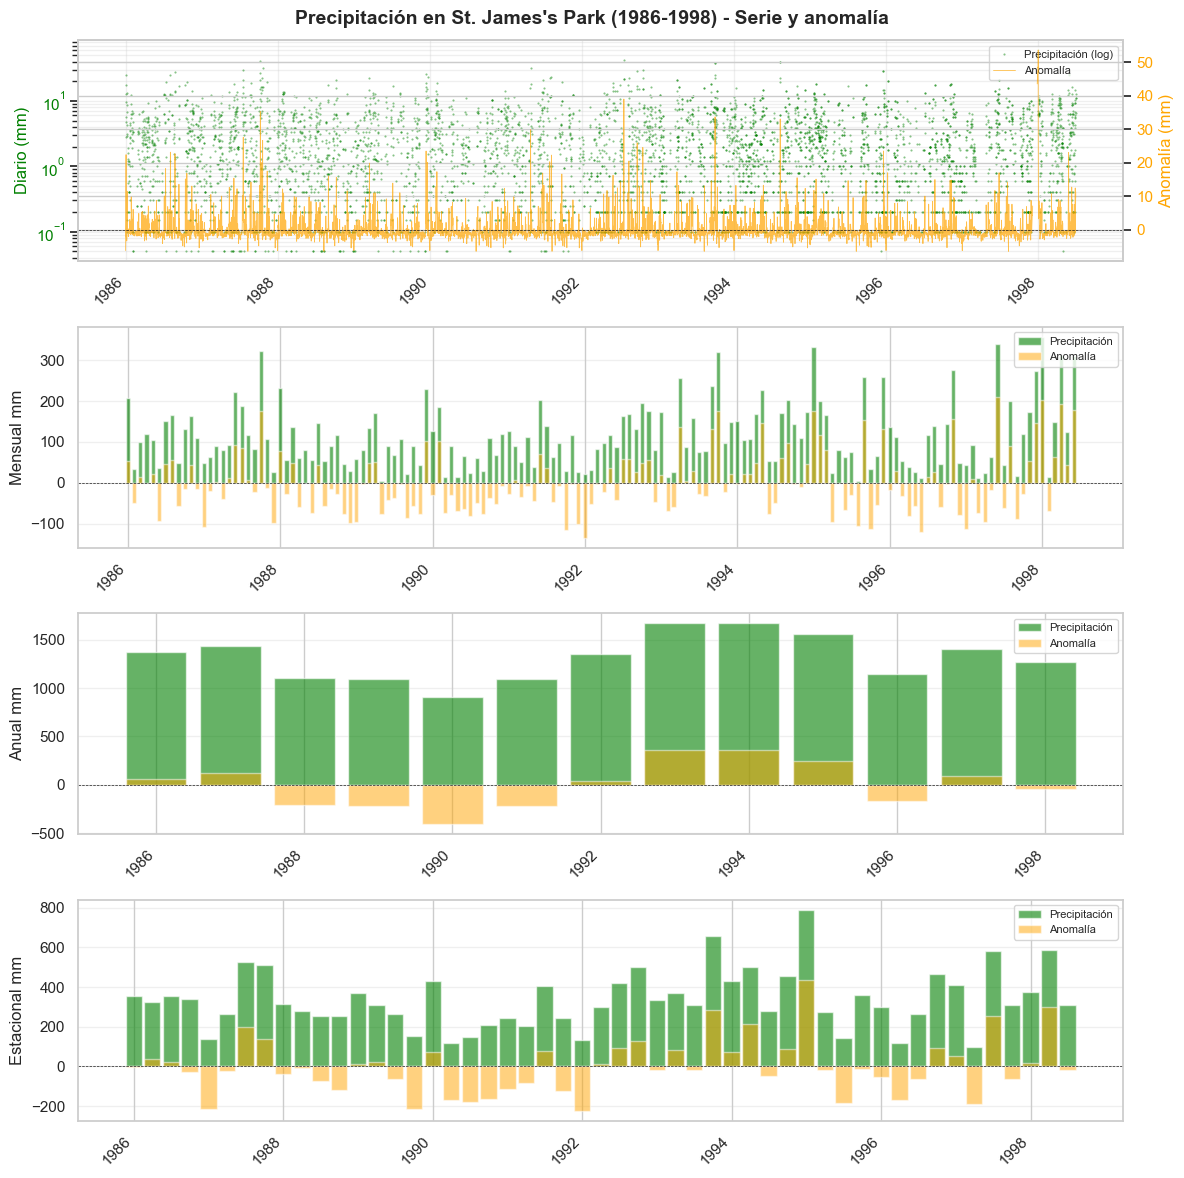

In [100]:
# ============================================================
# FIGURA 1: TEMPERATURA (4 paneles, serie y anomalía en mismo eje)
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle('Temperatura en St. James\'s Park (1986-1998) - Serie y anomalía', fontsize=14, fontweight='bold')

# Colores
color_temp = 'red'
color_anom = 'blue'

# Panel 1: Diario
ax = axes[0]
ax.plot(df_interp['date'], df_interp['tmean_interp'], color=color_temp, linewidth=0.6, alpha=0.8, label='Temperatura')
ax.plot(df_interp['date'], df_interp['tmean_anom_daily'], color=color_anom, linewidth=0.6, alpha=0.7, label='Anomalía')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Diario °C')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Mensual
ax = axes[1]
ax.plot(monthly_temp['date'], monthly_temp['tmean_interp'], color=color_temp, linewidth=1, label='Temperatura')
ax.bar(monthly_temp['date'], monthly_temp['tmean_anom'], width=20, color=color_anom, alpha=0.5, label='Anomalía')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Mensual °C')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Anual
ax = axes[2]
ax.plot(annual_temp['date'], annual_temp['tmean_interp'], color=color_temp, marker='s', markersize=4, linewidth=1, label='Temperatura')
ax.bar(annual_temp['date'], annual_temp['tmean_anom'], width=300, color=color_anom, alpha=0.5, label='Anomalía')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Anual °C')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Estacional
ax = axes[3]
ax.plot(seasonal_temp['date'], seasonal_temp['tmean_interp'], color=color_temp, linewidth=1, label='Temperatura')
ax.bar(seasonal_temp['date'], seasonal_temp['tmean_anom'], width=80, color=color_anom, alpha=0.5, label='Anomalía')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Estacional °C')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Formato de fechas común
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('temperatura_midas_1986_1998.png', dpi=300)
plt.show()

# ============================================================
# FIGURA 2: PRECIPITACIÓN (4 paneles, con eje secundario solo en diario)
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle('Precipitación en St. James\'s Park (1986-1998) - Serie y anomalía', fontsize=14, fontweight='bold')

# Colores
color_precip = 'green'
color_anom = 'orange'

# ---- Panel 1: Diario (con eje secundario para anomalía) ----
ax1 = axes[0]
# Serie en escala logarítmica (reemplazar 0 por NaN para evitar problemas con log)
precip_log = df_interp['precip_interp'].replace(0, np.nan)
ax1.semilogy(df_interp['date'], precip_log, color=color_precip, marker='.', markersize=1, linestyle='', alpha=0.5, label='Precipitación (log)')
ax1.set_ylabel('Diario (mm)', color=color_precip)
ax1.tick_params(axis='y', labelcolor=color_precip)
ax1.grid(True, alpha=0.3, which='both')

# Anomalía en eje secundario (escala lineal)
ax1b = ax1.twinx()
ax1b.plot(df_interp['date'], df_interp['precip_anom_daily'], color=color_anom, linewidth=0.6, alpha=0.7, label='Anomalía')
ax1b.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax1b.set_ylabel('Anomalía (mm)', color=color_anom)
ax1b.tick_params(axis='y', labelcolor=color_anom)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# ---- Panel 2: Mensual (mismo eje) ----
ax2 = axes[1]
ax2.bar(monthly_precip['date'], monthly_precip['precip_interp'], width=20, color=color_precip, alpha=0.6, label='Precipitación')
ax2.bar(monthly_precip['date'], monthly_precip['precip_anom'], width=20, color=color_anom, alpha=0.5, label='Anomalía')
ax2.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Mensual mm')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# ---- Panel 3: Anual (mismo eje) ----
ax3 = axes[2]
ax3.bar(annual_precip['date'], annual_precip['precip_interp'], width=300, color=color_precip, alpha=0.6, label='Precipitación')
ax3.bar(annual_precip['date'], annual_precip['precip_anom'], width=300, color=color_anom, alpha=0.5, label='Anomalía')
ax3.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax3.set_ylabel('Anual mm')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# ---- Panel 4: Estacional (mismo eje) ----
ax4 = axes[3]
ax4.bar(seasonal_precip['date'], seasonal_precip['precip_interp'], width=80, color=color_precip, alpha=0.6, label='Precipitación')
ax4.bar(seasonal_precip['date'], seasonal_precip['precip_anom'], width=80, color=color_anom, alpha=0.5, label='Anomalía')
ax4.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax4.set_ylabel('Estacional mm')
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

# Formato de fechas común para todos los ejes principales
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('precipitacion_midas_1986_1998.png', dpi=300)
plt.show()

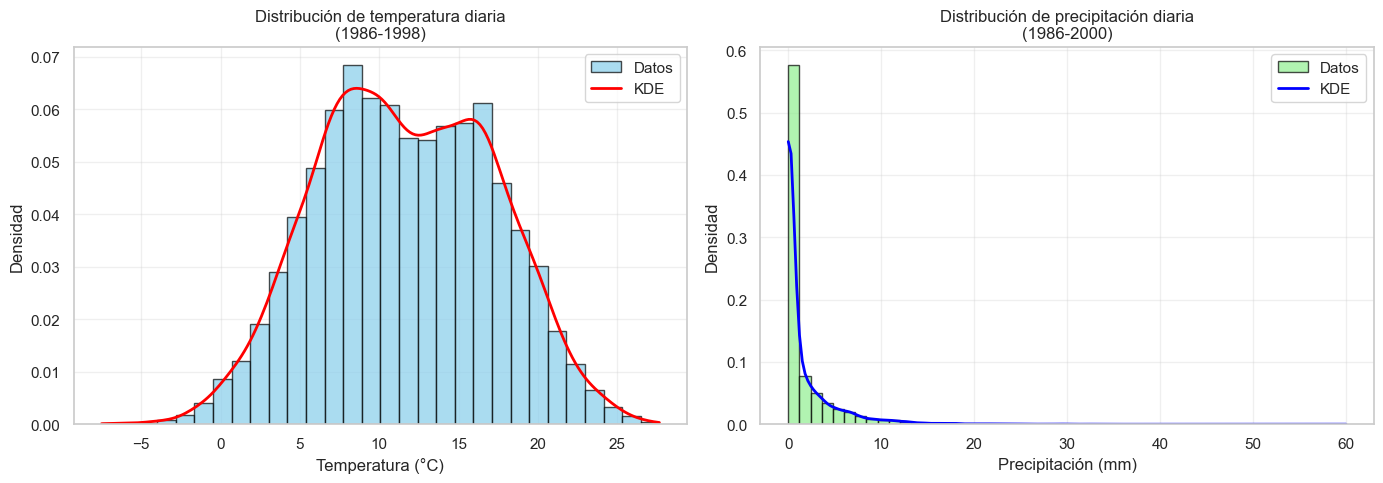

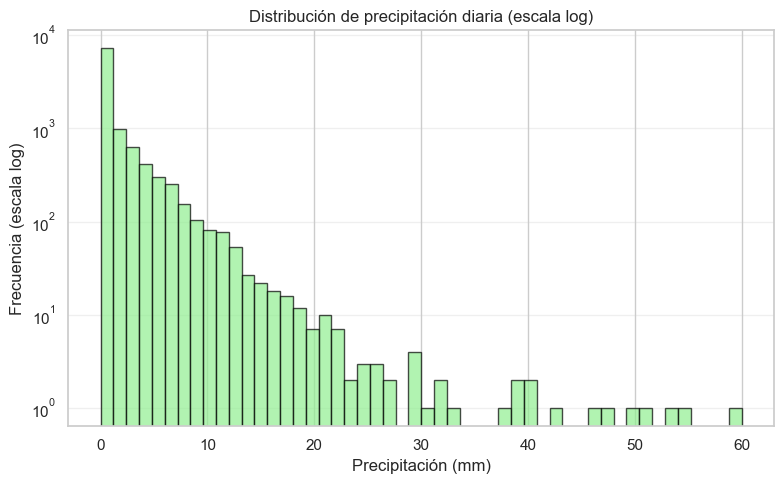

In [101]:
# ============================================================
# Cargar datos diarios (interpolados, para evitar NaN)
# ============================================================
df = pd.read_csv('../datos/midas_stjames_1986_1998_interp.csv', parse_dates=['date'])
df.rename(columns={'tmean': 'tmean_interp', 'precip': 'precip_interp'}, inplace=True)

# Eliminar valores NaN por si acaso (aunque la interpolación debería haberlos tratado)
temp_data = df['tmean_interp'].dropna()
precip_data = df['precip_interp'].dropna()

# ============================================================
# Crear figura con dos paneles: temperatura y precipitación
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- Histograma de temperatura ----------
axes[0].hist(temp_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7, density=True, label='Datos')
# Calcular KDE con scipy
kde_temp = gaussian_kde(temp_data)
x_vals_temp = np.linspace(temp_data.min(), temp_data.max(), 200)
axes[0].plot(x_vals_temp, kde_temp(x_vals_temp), color='red', linewidth=2, label='KDE')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de temperatura diaria\n(1986-1998)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---------- Histograma de precipitación ----------
axes[1].hist(precip_data, bins=50, color='lightgreen', edgecolor='black', alpha=0.7, density=True, label='Datos')
kde_precip = gaussian_kde(precip_data)
x_vals_precip = np.linspace(precip_data.min(), precip_data.max(), 200)
axes[1].plot(x_vals_precip, kde_precip(x_vals_precip), color='blue', linewidth=2, label='KDE')
axes[1].set_xlabel('Precipitación (mm)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de precipitación diaria\n(1986-2000)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histogramas_diarios.png', dpi=300)
plt.show()

# ============================================================
# (Opcional) Histograma de precipitación con escala log en Y
# para visualizar mejor la cola de valores altos
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.hist(precip_data, bins=50, color='lightgreen', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Precipitación (mm)')
ax2.set_ylabel('Frecuencia (escala log)')
ax2.set_title('Distribución de precipitación diaria (escala log)')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('histograma_precip_log.png', dpi=300)
plt.show()


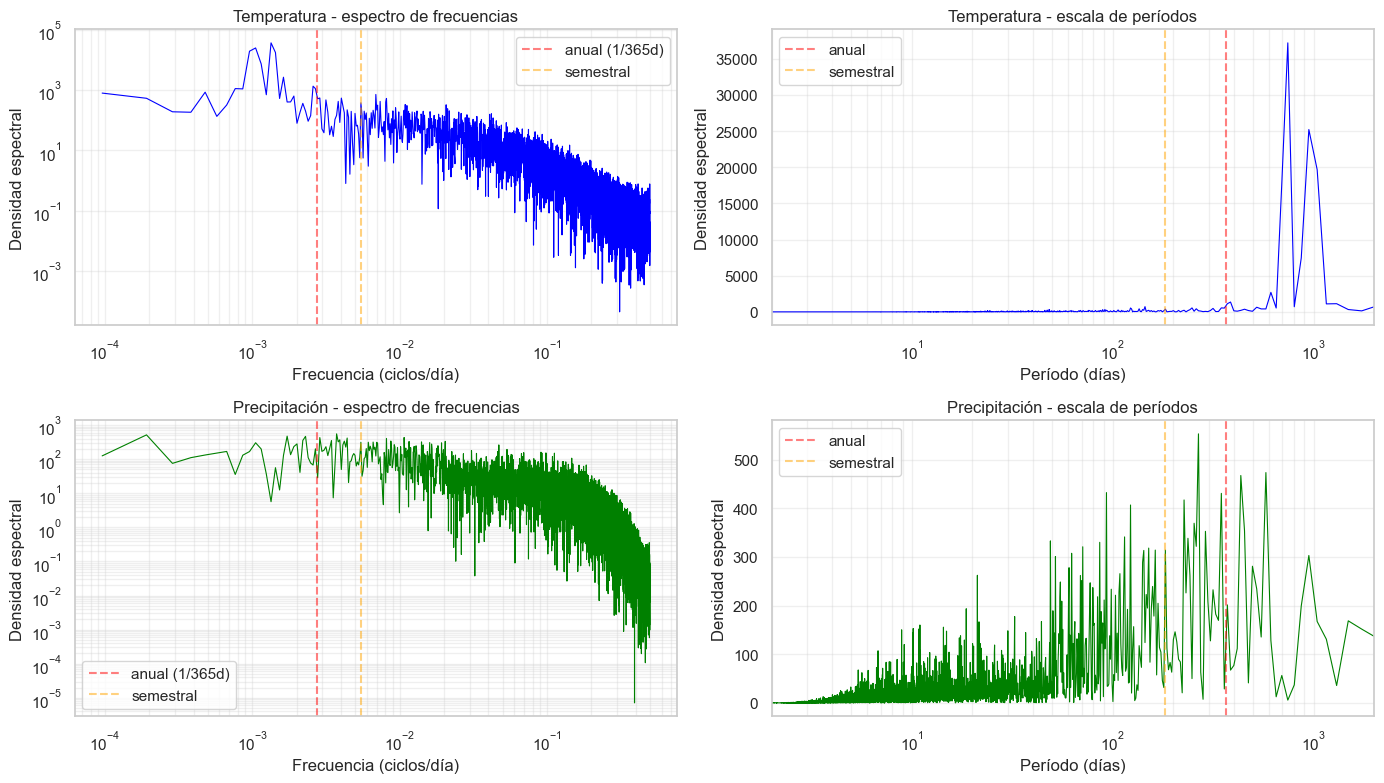

In [102]:
# ============================================================
# Cargar datos diarios interpolados
# ============================================================
df = pd.read_csv('../datos/midas_stjames_1986_1998_interp.csv', parse_dates=['date'])
df.rename(columns={'tmean': 'tmean_interp', 'precip': 'precip_interp'}, inplace=True)

# Ordenar por fecha
df = df.sort_values('date').reset_index(drop=True)

# Verificar y eliminar cualquier NaN residual (interpolación lineal completa)
if df['tmean_interp'].isna().any():
    
    df['tmean_interp'] = df['tmean_interp'].interpolate(method='linear', limit_direction='both')
if df['precip_interp'].isna().any():
    
    df['precip_interp'] = df['precip_interp'].interpolate(method='linear', limit_direction='both')

# Asegurar que no queden NaN (si los hay, se eliminan las filas)
df = df.dropna().reset_index(drop=True)

# Extraer series
temp = df['tmean_interp'].values
precip = df['precip_interp'].values

# ============================================================
# Parámetros para FFT
# ============================================================
n = len(temp)
dt = 1.0  # muestreo diario
frecuencias = fftfreq(n, d=dt)[:n//2]          # frecuencias positivas
periodos = 1 / frecuencias[1:]                  # períodos (omitir frecuencia cero)

# ============================================================
# Función para calcular y graficar espectro
# ============================================================
def plot_spectrum(serie, titulo, color, ax_freq=None, ax_per=None):
    # Eliminar tendencia lineal (mejora el espectro en bajas frecuencias)
    serie_detrend = signal.detrend(serie)
    
    # Calcular FFT y potencia
    fft_vals = fft(serie_detrend)
    potencia = np.abs(fft_vals[:n//2])**2 / n   # normalización
    
    # Gráfico en frecuencia (escala log-log)
    if ax_freq is not None:
        ax_freq.loglog(frecuencias[1:], potencia[1:], color=color, linewidth=0.8)
        ax_freq.set_xlabel('Frecuencia (ciclos/día)')
        ax_freq.set_ylabel('Densidad espectral')
        ax_freq.set_title(titulo + ' - espectro de frecuencias')
        ax_freq.grid(True, alpha=0.3, which='both')
        # Líneas de referencia
        ax_freq.axvline(1/365.25, color='red', linestyle='--', alpha=0.5, label='anual (1/365d)')
        ax_freq.axvline(2/365.25, color='orange', linestyle='--', alpha=0.5, label='semestral')
        ax_freq.legend()
    
    # Gráfico en períodos (escala semilog)
    if ax_per is not None:
        ax_per.semilogx(periodos, potencia[1:], color=color, linewidth=0.8)
        ax_per.set_xlabel('Período (días)')
        ax_per.set_ylabel('Densidad espectral')
        ax_per.set_title(titulo + ' - escala de períodos')
        ax_per.axvline(365.25, color='red', linestyle='--', alpha=0.5, label='anual')
        ax_per.axvline(182.6, color='orange', linestyle='--', alpha=0.5, label='semestral')
        ax_per.set_xlim([2, 2000])
        ax_per.grid(True, alpha=0.3, which='both')
        ax_per.legend()

# ============================================================
# Crear figura con dos columnas: frecuencia y período
# ============================================================
fig, ((ax1_freq, ax1_per), (ax2_freq, ax2_per)) = plt.subplots(2, 2, figsize=(14, 8))

# Temperatura
plot_spectrum(temp, 'Temperatura', 'blue', ax_freq=ax1_freq, ax_per=ax1_per)
# Precipitación
plot_spectrum(precip, 'Precipitación', 'green', ax_freq=ax2_freq, ax_per=ax2_per)

plt.tight_layout()
plt.savefig('fourier_completo.png', dpi=300)
plt.show()